# Análise de Preços de Veículos Usados

Este notebook realiza uma análise de dados de preços de veículos usados e utiliza técnicas de aprendizado de máquina para prever se um veículo será vendido. As etapas incluem:

1. **Carregamento e preparação dos dados**: Importação dos dados de um arquivo CSV, limpeza e transformação dos dados.
2. **Divisão dos dados**: Separação dos dados em conjuntos de treino e teste.
3. **Treinamento do modelo**: Treinamento de diferentes modelos de classificação, incluindo SVM e DummyClassifier, para prever a venda dos veículos.
4. **Avaliação do modelo**: Avaliação da precisão dos modelos utilizando o conjunto de teste.
5. **Visualização dos resultados**: Criação de gráficos para visualizar a performance dos modelos e a distribuição dos dados.

In [19]:
import pandas as pd

dados = pd.read_csv('precos.csv', delimiter = ',')
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido
0,21801,2000,30941.02,1
1,7843,1998,40557.96,1
2,7109,2006,89627.50,0
3,26823,2015,95276.14,0
4,7935,2014,117384.68,1


In [20]:
dados["km_por_ano"] = dados["milhas_por_ano"] * 1.60934
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano
0,21801,2000,30941.02,1,35085.22134
1,7843,1998,40557.96,1,12622.05362
2,7109,2006,89627.50,0,11440.79806
3,26823,2015,95276.14,0,43167.32682
4,7935,2014,117384.68,1,12770.11290


In [21]:
from datetime import datetime

dados["idade"] = datetime.today().year - dados["ano_do_modelo"]
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano,idade
0,21801,2000,30941.02,1,35085.22134,24
1,7843,1998,40557.96,1,12622.05362,26
2,7109,2006,89627.50,0,11440.79806,18
3,26823,2015,95276.14,0,43167.32682,9
4,7935,2014,117384.68,1,12770.11290,10


In [22]:
dados.drop(["milhas_por_ano", "ano_do_modelo"], axis = 1, inplace = True)
dados.head()

,preco,vendido,km_por_ano,idade
0,30941.02,1,35085.22134,24
1,40557.96,1,12622.05362,26
2,89627.50,0,11440.79806,18
3,95276.14,0,43167.32682,9
4,117384.68,1,12770.11290,10


In [23]:
# Com SVC

from sklearn.model_selection  import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

x = dados[["preco", "idade", "km_por_ano"]]
y = dados["vendido"]
 
SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = SVC(gamma = 'auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurária foi de {acuracia: .2f}")

Treinaremos com 7500
Testaremos com 2500
A acurária foi de  75.92


In [24]:
# Com LinearSVC

from sklearn.model_selection  import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

x = dados[["preco", "idade", "km_por_ano"]]
y = dados["vendido"]
 
SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurária foi de {acuracia: .2f}")

Treinaremos com 7500
Testaremos com 2500
A acurária foi de  69.92


In [25]:
# DummyClassifier

from sklearn.model_selection  import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

x = dados[["preco", "idade", "km_por_ano"]]
y = dados["vendido"]
 
SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, stratify = y)

print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")

classificador = DummyClassifier(strategy = 'stratified')
classificador.fit(treino_x, treino_y)
previsoes = classificador.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurária foi de {acuracia: .2f}")

Treinaremos com 7500
Testaremos com 2500
A acurária foi de  50.72


# Árvores de Decisão

In [29]:
from sklearn.model_selection  import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

x = dados[["preco", "idade", "km_por_ano"]]
y = dados["vendido"]
 
SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state = SEED, stratify = y)

print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo = DecisionTreeClassifier(max_depth = 3)
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurária foi de {acuracia: .2f}")

Treinaremos com 7500
Testaremos com 2500
A acurária foi de  78.40


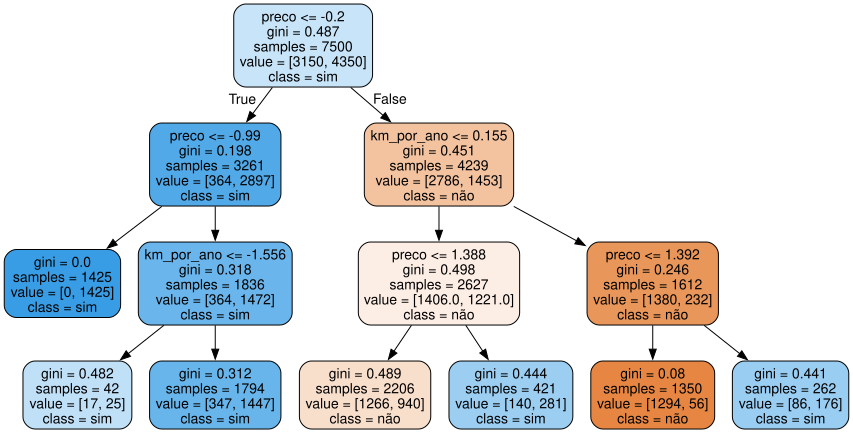

In [32]:
from sklearn.tree import export_graphviz
import graphviz

estrutura = export_graphviz(modelo, filled = True, rounded = True, feature_names = x.columns, class_names = ["não", "sim"])
grafico = graphviz.Source(estrutura)
grafico